In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

In [2]:
file_path = "D:\Admin\OneDrive - presidencyuniversity.in\Desktop\Bank_Churn_Messy.xlsx"

customer_df = pd.read_excel(
    file_path,
    sheet_name="Customer_Info"
)

account_df = pd.read_excel(
    file_path,
    sheet_name="Account_Info"
)

customer_df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary
0,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88
1,15647311,Hill,608,Spain,Female,41.0,1,€112542.58
2,15619304,Onio,502,French,Female,42.0,8,€113931.57
3,15701354,Boni,699,FRA,Female,39.0,1,€93826.63
4,15737888,Mitchell,850,Spain,Female,43.0,2,€79084.1


In [3]:
account_df.head()

,CustomerId,Balance,NumOfProducts,HasCrCard,Tenure,IsActiveMember,Exited
0,15634602,€0.0,1,Yes,2,Yes,1
1,15634602,€0.0,1,Yes,2,Yes,1
2,15647311,€83807.86,1,Yes,1,Yes,0
3,15619304,€159660.8,3,No,8,No,1
4,15701354,€0.0,2,No,1,No,0


In [4]:
print("Customer Info:", customer_df.shape)
print("Account Info:", account_df.shape)

Customer Info: (10001, 8)
Account Info: (10002, 7)


In [5]:
customer_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10001 entries, 0 to 10000
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10001 non-null  int64  
 1   Surname          9998 non-null   str    
 2   CreditScore      10001 non-null  int64  
 3   Geography        10001 non-null  str    
 4   Gender           10001 non-null  str    
 5   Age              9998 non-null   float64
 6   Tenure           10001 non-null  int64  
 7   EstimatedSalary  10001 non-null  str    
dtypes: float64(1), int64(3), str(4)
memory usage: 901.8 KB


In [6]:
account_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10002 entries, 0 to 10001
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   CustomerId      10002 non-null  int64
 1   Balance         10002 non-null  str  
 2   NumOfProducts   10002 non-null  int64
 3   HasCrCard       10002 non-null  str  
 4   Tenure          10002 non-null  int64
 5   IsActiveMember  10002 non-null  str  
 6   Exited          10002 non-null  int64
dtypes: int64(4), str(3)
memory usage: 690.1 KB


In [7]:
customer_df.describe(include="all")

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary
count,1.000100e+04,9998,10001.000000,10001,10001,9998.000000,10001.000000,10001
unique,NaN,2932,NaN,5,2,NaN,NaN,9997
top,NaN,Smith,NaN,Germany,Male,NaN,NaN,-€999999
freq,NaN,32,NaN,2509,5457,NaN,NaN,3
mean,1.569093e+07,NaN,650.542946,NaN,NaN,38.920984,5.012699,NaN
std,7.193531e+04,NaN,96.658818,NaN,NaN,10.489116,2.892047,NaN
min,1.556570e+07,NaN,350.000000,NaN,NaN,18.000000,0.000000,NaN
25%,1.562852e+07,NaN,584.000000,NaN,NaN,32.000000,3.000000,NaN
50%,1.569073e+07,NaN,652.000000,NaN,NaN,37.000000,5.000000,NaN
75%,1.575323e+07,NaN,718.000000,NaN,NaN,44.000000,7.000000,NaN


In [8]:
customer_df.describe(include="all")

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary
count,1.000100e+04,9998,10001.000000,10001,10001,9998.000000,10001.000000,10001
unique,NaN,2932,NaN,5,2,NaN,NaN,9997
top,NaN,Smith,NaN,Germany,Male,NaN,NaN,-€999999
freq,NaN,32,NaN,2509,5457,NaN,NaN,3
mean,1.569093e+07,NaN,650.542946,NaN,NaN,38.920984,5.012699,NaN
std,7.193531e+04,NaN,96.658818,NaN,NaN,10.489116,2.892047,NaN
min,1.556570e+07,NaN,350.000000,NaN,NaN,18.000000,0.000000,NaN
25%,1.562852e+07,NaN,584.000000,NaN,NaN,32.000000,3.000000,NaN
50%,1.569073e+07,NaN,652.000000,NaN,NaN,37.000000,5.000000,NaN
75%,1.575323e+07,NaN,718.000000,NaN,NaN,44.000000,7.000000,NaN


In [9]:
print("Customer Info missing values:")
print(customer_df.isnull().sum())

Customer Info missing values:
CustomerId         0
Surname            3
CreditScore        0
Geography          0
Gender             0
Age                3
Tenure             0
EstimatedSalary    0
dtype: int64


In [10]:
print("Account Info missing values:")
print(account_df.isnull().sum())

Account Info missing values:
CustomerId        0
Balance           0
NumOfProducts     0
HasCrCard         0
Tenure            0
IsActiveMember    0
Exited            0
dtype: int64


In [11]:
print(
    "Customer duplicate rows:",
    customer_df.duplicated().sum()
)

print(
    "Account duplicate rows:",
    account_df.duplicated().sum()
)

Customer duplicate rows: 1
Account duplicate rows: 2


In [12]:
print(
    "Duplicate Customer IDs in Customer_Info:",
    customer_df["CustomerId"].duplicated().sum()
)

Duplicate Customer IDs in Customer_Info: 1


In [13]:
print(
    "Duplicate Customer IDs in Account_Info:",
    account_df["CustomerId"].duplicated().sum()
)

Duplicate Customer IDs in Account_Info: 2


In [14]:
customer_df[
    customer_df["CustomerId"].duplicated(keep=False)
]

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary
9999,15628319,Walker,792,French,Female,28.0,4,€38190.78
10000,15628319,Walker,792,French,Female,28.0,4,€38190.78


In [15]:
account_df[
    account_df["CustomerId"].duplicated(keep=False)
]

,CustomerId,Balance,NumOfProducts,HasCrCard,Tenure,IsActiveMember,Exited
0,15634602,€0.0,1,Yes,2,Yes,1
1,15634602,€0.0,1,Yes,2,Yes,1
10000,15628319,€130142.79,1,No,4,No,0
10001,15628319,€130142.79,1,No,4,No,0


In [16]:
customer_df["Geography"].value_counts()

Geography
Germany    2509
Spain      2477
France     1741
French     1656
FRA        1618
Name: count, dtype: int64

In [17]:
customer_df[
    ["CreditScore", "Age", "Tenure"]
].describe()

,CreditScore,Age,Tenure
count,10001.000000,9998.000000,10001.000000
mean,650.542946,38.920984,5.012699
std,96.658818,10.489116,2.892047
min,350.000000,18.000000,0.000000
25%,584.000000,32.000000,3.000000
50%,652.000000,37.000000,5.000000
75%,718.000000,44.000000,7.000000
max,850.000000,92.000000,10.000000


In [18]:
account_df[
    ["NumOfProducts", "Tenure", "Exited"]
].describe()

,NumOfProducts,Tenure,Exited
count,10002.000000,10002.000000,10002.000000
mean,1.530094,5.012398,0.203759
std,0.581645,2.892060,0.402812
min,1.000000,0.000000,0.000000
25%,1.000000,3.000000,0.000000
50%,1.000000,5.000000,0.000000
75%,2.000000,7.000000,0.000000
max,4.000000,10.000000,1.000000


In [19]:
print(
    customer_df[
        (customer_df["CreditScore"] < 300) |
        (customer_df["CreditScore"] > 850)
    ]
)

Empty DataFrame
Columns: [CustomerId, Surname, CreditScore, Geography, Gender, Age, Tenure, EstimatedSalary]
Index: []


In [20]:
print(
    customer_df[
        (customer_df["Age"] < 18) |
        (customer_df["Age"] > 100)
    ]
)

Empty DataFrame
Columns: [CustomerId, Surname, CreditScore, Geography, Gender, Age, Tenure, EstimatedSalary]
Index: []


In [21]:
print(
    customer_df[
        (customer_df["Tenure"] < 0) |
        (customer_df["Tenure"] > 10)
    ]
)

Empty DataFrame
Columns: [CustomerId, Surname, CreditScore, Geography, Gender, Age, Tenure, EstimatedSalary]
Index: []


In [22]:
print(
    account_df[
        (account_df["NumOfProducts"] < 1) |
        (account_df["NumOfProducts"] > 4)
    ]
)

Empty DataFrame
Columns: [CustomerId, Balance, NumOfProducts, HasCrCard, Tenure, IsActiveMember, Exited]
Index: []


In [23]:
customer_clean = customer_df.copy()
account_clean = account_df.copy()

In [24]:
customer_clean = customer_clean.drop_duplicates()
account_clean = account_clean.drop_duplicates()

In [25]:
print(customer_clean.duplicated().sum())
print(account_clean.duplicated().sum())

0
0


In [26]:
print(
    customer_clean["CustomerId"].duplicated().sum()
)

print(
    account_clean["CustomerId"].duplicated().sum()
)

0
0


In [27]:
customer_clean["Geography"] = customer_clean["Geography"].replace({
    "French": "France",
    "FRA": "France"
})

In [28]:
customer_clean["Geography"].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [29]:
customer_clean["EstimatedSalary"] = (
    customer_clean["EstimatedSalary"]
    .str.replace("€", "", regex=False)
    .str.replace(",", "", regex=False)
)

In [30]:
customer_clean["EstimatedSalary"] = pd.to_numeric(
    customer_clean["EstimatedSalary"],
    errors="coerce"
)

In [31]:
customer_clean[
    customer_clean["EstimatedSalary"] < 0
]

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary
28,15728693,NaN,574,Germany,Female,NaN,3,-999999.0
121,15580203,NaN,674,Spain,Male,NaN,6,-999999.0
9389,15756954,NaN,538,France,Female,NaN,2,-999999.0


In [32]:
customer_clean.loc[
    customer_clean["EstimatedSalary"] < 0,
    "EstimatedSalary"
] = np.nan

In [33]:
account_clean["Balance"] = (
    account_clean["Balance"]
    .str.replace("€", "", regex=False)
    .str.replace(",", "", regex=False)
)

In [34]:
account_clean["Balance"] = pd.to_numeric(
    account_clean["Balance"],
    errors="coerce"
)

In [35]:
account_clean["Balance"].describe()

count     10000.000000
mean      76485.889288
std       62397.405202
min           0.000000
25%           0.000000
50%       97198.540000
75%      127644.240000
max      250898.090000
Name: Balance, dtype: float64

In [36]:
account_clean["HasCrCard"] = account_clean["HasCrCard"].map({
    "Yes": 1,
    "No": 0
})

In [37]:
account_clean["IsActiveMember"] = account_clean["IsActiveMember"].map({
    "Yes": 1,
    "No": 0
})

In [38]:
print(account_clean["HasCrCard"].value_counts())
print(account_clean["IsActiveMember"].value_counts())

HasCrCard
1    5151
0    4849
Name: count, dtype: int64
IsActiveMember
1    5151
0    4849
Name: count, dtype: int64


In [39]:
bank_df = pd.merge(
    customer_clean,
    account_clean,
    on="CustomerId",
    how="left"
)

In [40]:
bank_df.shape

(10000, 14)

In [41]:
bank_df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure_x,EstimatedSalary,Balance,NumOfProducts,HasCrCard,Tenure_y,IsActiveMember,Exited
0,15634602,Hargrave,619,France,Female,42.0,2,101348.88,0.00,1,1,2,1,1
1,15647311,Hill,608,Spain,Female,41.0,1,112542.58,83807.86,1,1,1,1,0
2,15619304,Onio,502,France,Female,42.0,8,113931.57,159660.80,3,0,8,0,1
3,15701354,Boni,699,France,Female,39.0,1,93826.63,0.00,2,0,1,0,0
4,15737888,Mitchell,850,Spain,Female,43.0,2,79084.10,125510.82,1,1,2,1,0


In [42]:
bank_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          9997 non-null   str    
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  str    
 4   Gender           10000 non-null  str    
 5   Age              9997 non-null   float64
 6   Tenure_x         10000 non-null  int64  
 7   EstimatedSalary  9997 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  Tenure_y         10000 non-null  int64  
 12  IsActiveMember   10000 non-null  int64  
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), str(3)
memory usage: 1.2 MB


In [45]:
bank_df.columns

Index(['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age',
       'Tenure_x', 'EstimatedSalary', 'Balance', 'NumOfProducts', 'HasCrCard',
       'Tenure_y', 'IsActiveMember', 'Exited'],
      dtype='str')

In [47]:
print(
    "Unique CustomerIDs:",
    bank_df["CustomerId"].nunique()
)

Unique CustomerIDs: 10000


In [48]:
print(
    "Total rows:",
    len(bank_df)
)

Total rows: 10000


In [49]:
duplicate_rows = bank_df.duplicated().sum()

print("Duplicate rows:", duplicate_rows)

Duplicate rows: 0


In [51]:
(
    bank_df["Tenure_x"] ==
    bank_df["Tenure_y"]
).value_counts()

True    10000
Name: count, dtype: int64

In [52]:
bank_df = bank_df.drop(
    columns=["Tenure_y"]
)

In [53]:
bank_df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure_x,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
0,15634602,Hargrave,619,France,Female,42.0,2,101348.88,0.00,1,1,1,1
1,15647311,Hill,608,Spain,Female,41.0,1,112542.58,83807.86,1,1,1,0
2,15619304,Onio,502,France,Female,42.0,8,113931.57,159660.80,3,0,0,1
3,15701354,Boni,699,France,Female,39.0,1,93826.63,0.00,2,0,0,0
4,15737888,Mitchell,850,Spain,Female,43.0,2,79084.10,125510.82,1,1,1,0


In [54]:
bank_df.isnull().sum()

CustomerId         0
Surname            3
CreditScore        0
Geography          0
Gender             0
Age                3
Tenure_x           0
EstimatedSalary    3
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
Exited             0
dtype: int64

In [55]:
bank_df["Surname"] = bank_df["Surname"].fillna(
    "Unknown"
)

In [56]:
bank_df["Age"] = bank_df["Age"].fillna(
    bank_df["Age"].median()
)

In [57]:
bank_df["EstimatedSalary"] = bank_df["EstimatedSalary"].fillna(
    bank_df["EstimatedSalary"].median()
)

In [58]:
bank_df.isnull().sum()

CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure_x           0
EstimatedSalary    0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
Exited             0
dtype: int64

In [59]:
print(bank_df["Exited"].value_counts())

Exited
0    7963
1    2037
Name: count, dtype: int64


In [60]:
print(bank_df["Exited"].unique())

[1 0]


In [61]:
churn_counts = bank_df["Exited"].value_counts().sort_index()

churn_counts.index = [
    "Non-Churners",
    "Churners"
]

print(churn_counts)

Non-Churners    7963
Churners        2037
Name: count, dtype: int64


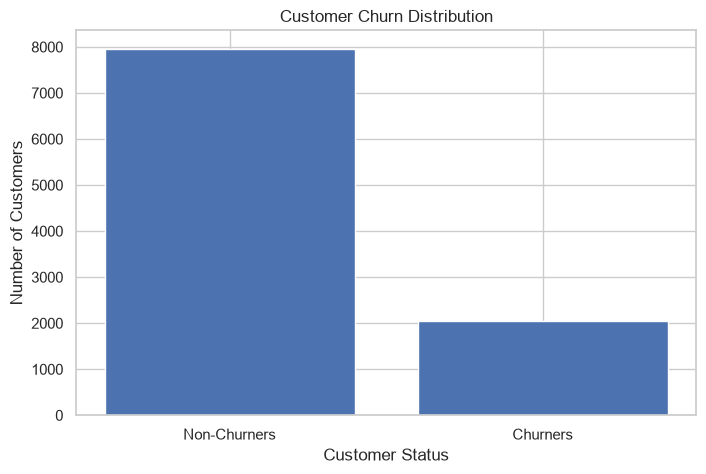

In [62]:
plt.figure(figsize=(8, 5))

plt.bar(
    churn_counts.index,
    churn_counts.values
)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

plt.show()

In [63]:
categorical_columns = bank_df.select_dtypes(
    include=["object", "category"]
).columns

print(categorical_columns.tolist())

['Surname', 'Geography', 'Gender']


C:\Users\Admin\AppData\Local\Temp\ipykernel_17244\1442639802.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = bank_df.select_dtypes(


In [64]:
print(
    pd.crosstab(
        bank_df["Geography"],
        bank_df["Exited"]
    )
)

Exited        0    1
Geography           
France     4204  810
Germany    1695  814
Spain      2064  413


In [65]:
print(
    pd.crosstab(
        bank_df["Gender"],
        bank_df["Exited"]
    )
)

Exited     0     1
Gender            
Female  3404  1139
Male    4559   898


In [66]:
geography_churn = (
    bank_df.groupby("Geography")["Exited"]
    .mean()
    .mul(100)
)

print(geography_churn)

Geography
France     16.154767
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64


In [67]:
gender_churn = (
    bank_df.groupby("Gender")["Exited"]
    .mean()
    .mul(100)
)

print(gender_churn)

Gender
Female    25.071539
Male      16.455928
Name: Exited, dtype: float64


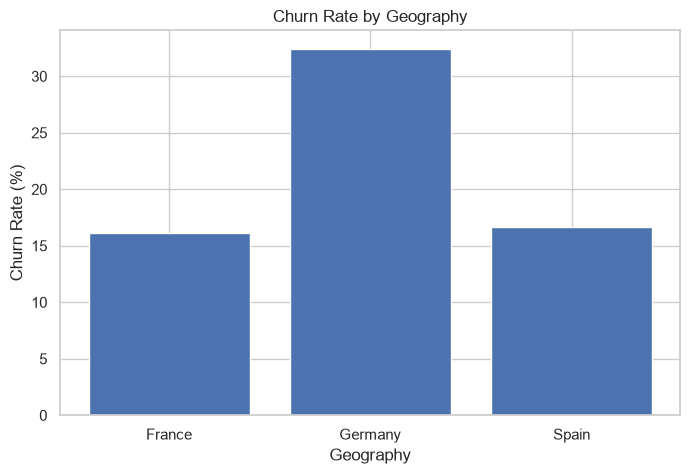

In [68]:
plt.figure(figsize=(8, 5))

plt.bar(
    geography_churn.index,
    geography_churn.values
)

plt.title("Churn Rate by Geography")
plt.xlabel("Geography")
plt.ylabel("Churn Rate (%)")

plt.show()

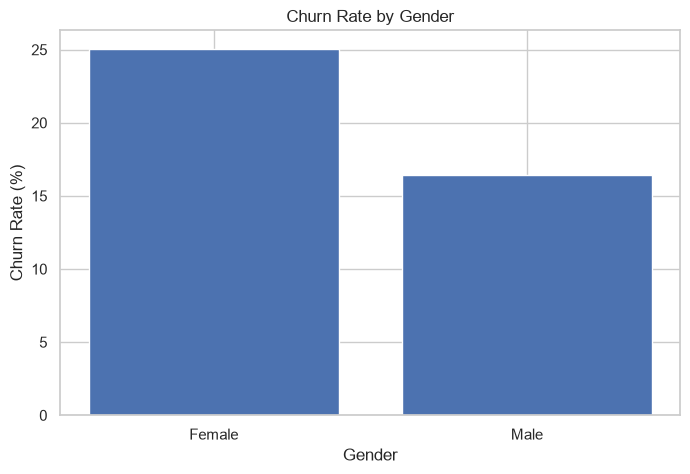

In [69]:
plt.figure(figsize=(8, 5))

plt.bar(
    gender_churn.index,
    gender_churn.values
)

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")

plt.show()

In [70]:
numeric_columns = bank_df.select_dtypes(
    include=["number"]
).columns

print(numeric_columns.tolist())

['CustomerId', 'CreditScore', 'Age', 'Tenure_x', 'EstimatedSalary', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'Exited']


In [71]:
numeric_columns = [
    column for column in numeric_columns
    if column != "Exited"
]

print(numeric_columns)

['CustomerId', 'CreditScore', 'Age', 'Tenure_x', 'EstimatedSalary', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember']


<Figure size 800x500 with 0 Axes>

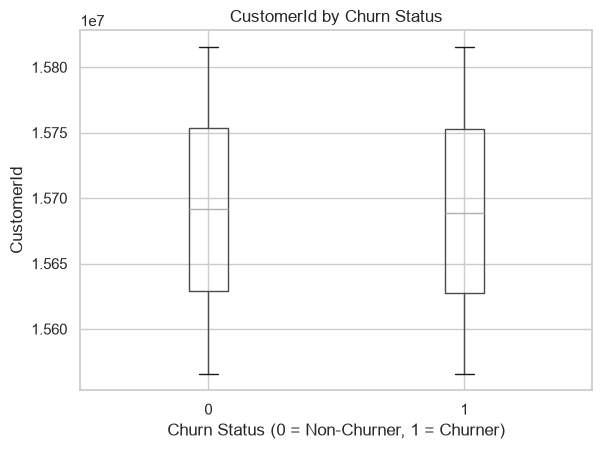

<Figure size 800x500 with 0 Axes>

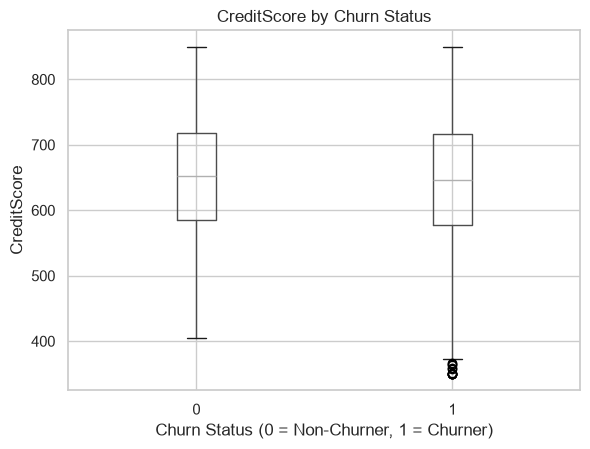

<Figure size 800x500 with 0 Axes>

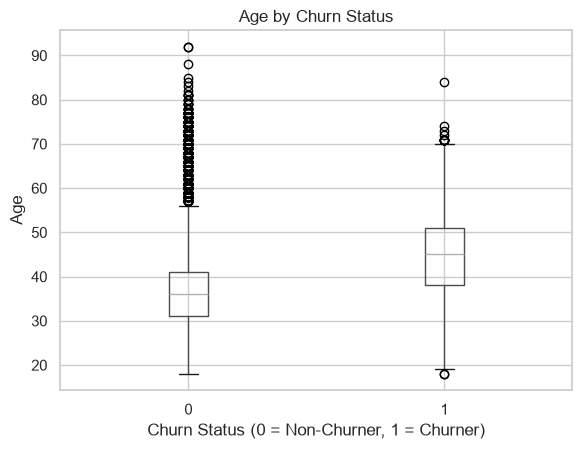

<Figure size 800x500 with 0 Axes>

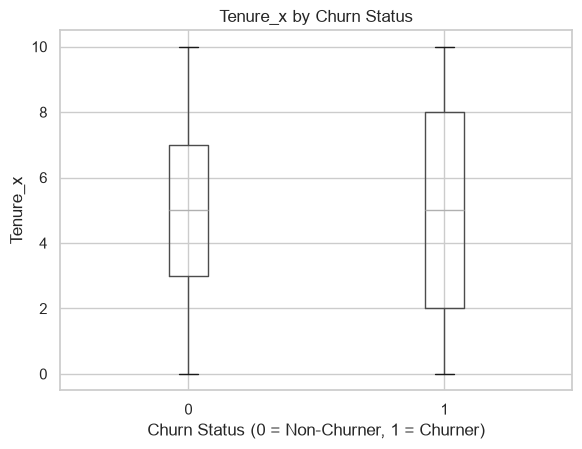

<Figure size 800x500 with 0 Axes>

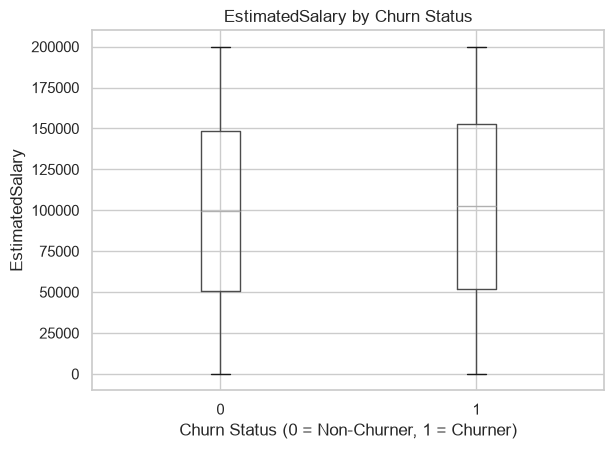

<Figure size 800x500 with 0 Axes>

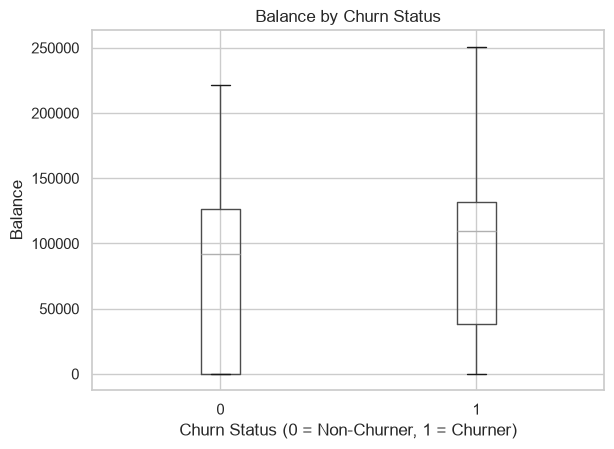

<Figure size 800x500 with 0 Axes>

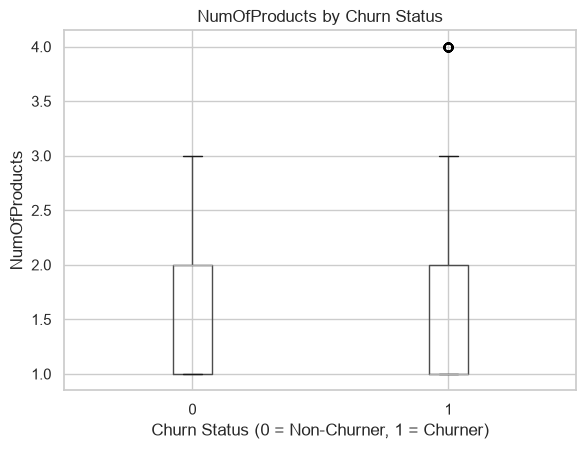

<Figure size 800x500 with 0 Axes>

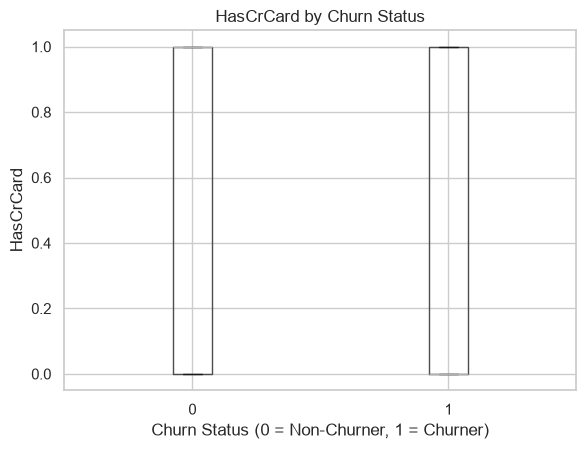

<Figure size 800x500 with 0 Axes>

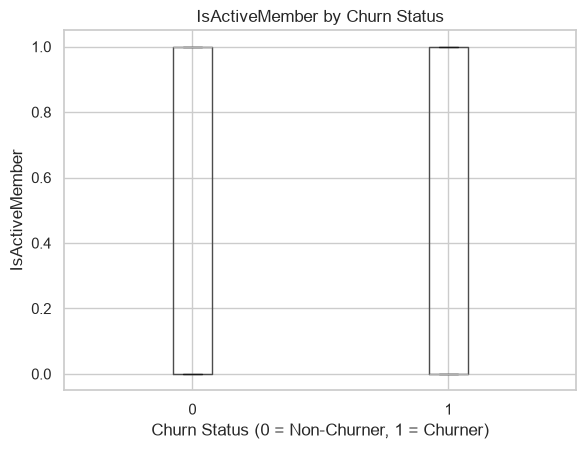

In [72]:
for column in numeric_columns:

    plt.figure(figsize=(8, 5))

    bank_df.boxplot(
        column=column,
        by="Exited"
    )

    plt.title(f"{column} by Churn Status")
    plt.suptitle("")
    plt.xlabel("Churn Status (0 = Non-Churner, 1 = Churner)")
    plt.ylabel(column)

    plt.show()

In [73]:
numeric_columns = [
    column for column in numeric_columns
    if column not in ["CustomerId"]
]

<Figure size 800x500 with 0 Axes>

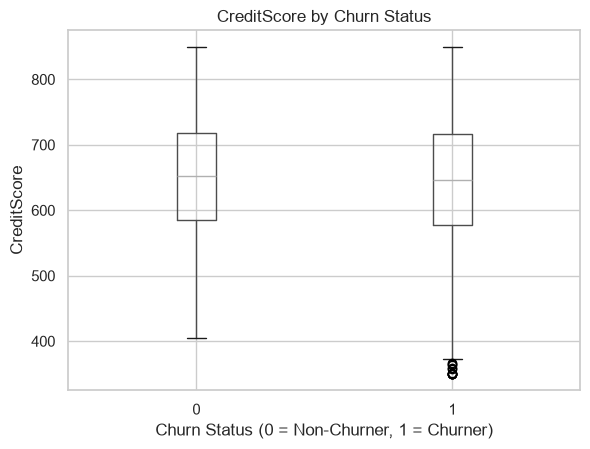

<Figure size 800x500 with 0 Axes>

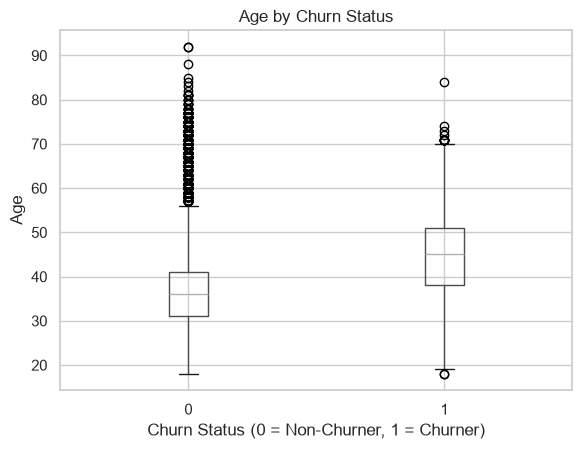

<Figure size 800x500 with 0 Axes>

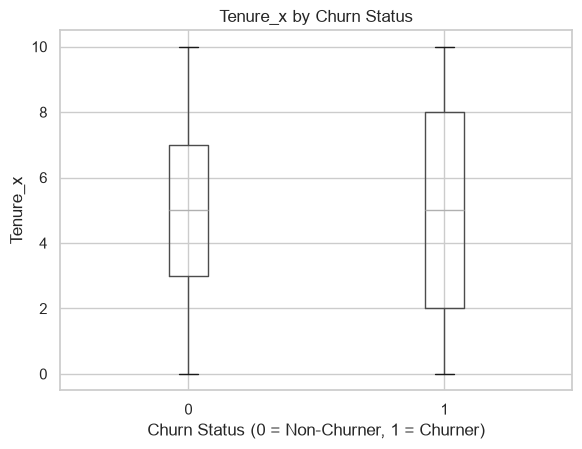

<Figure size 800x500 with 0 Axes>

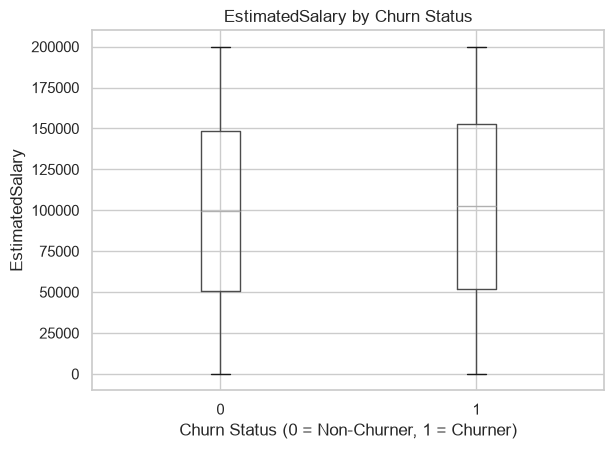

<Figure size 800x500 with 0 Axes>

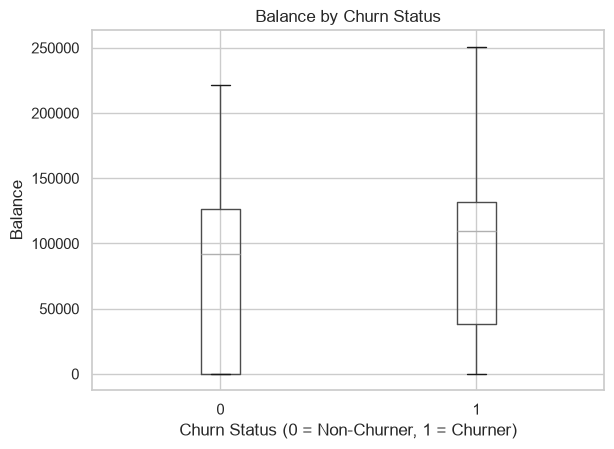

<Figure size 800x500 with 0 Axes>

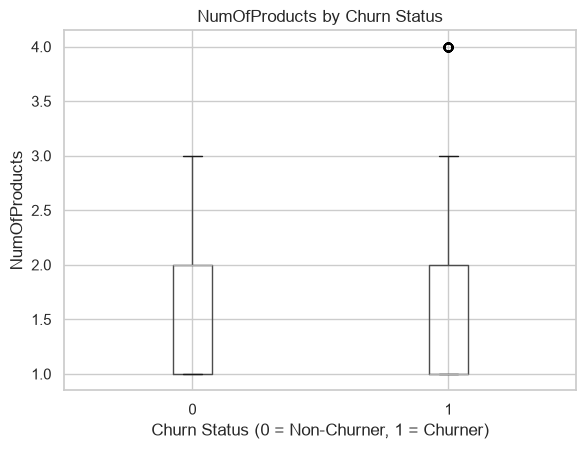

<Figure size 800x500 with 0 Axes>

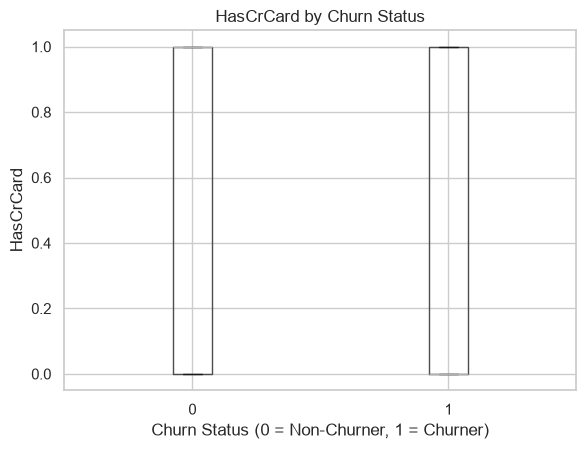

<Figure size 800x500 with 0 Axes>

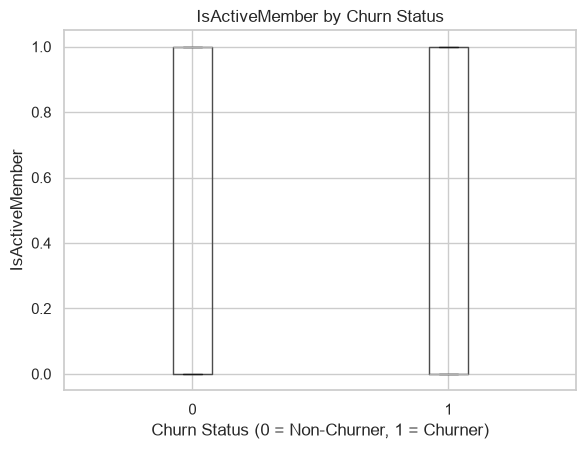

In [74]:
for column in numeric_columns:

    plt.figure(figsize=(8, 5))

    bank_df.boxplot(
        column=column,
        by="Exited"
    )

    plt.title(f"{column} by Churn Status")
    plt.suptitle("")
    plt.xlabel("Churn Status (0 = Non-Churner, 1 = Churner)")
    plt.ylabel(column)

    plt.show()

In [75]:
numeric_columns = bank_df.select_dtypes(
    include=["number"]
).columns

numeric_columns = [
    column for column in numeric_columns
    if column not in ["Exited", "CustomerId"]
]

print(numeric_columns)

['CreditScore', 'Age', 'Tenure_x', 'EstimatedSalary', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember']


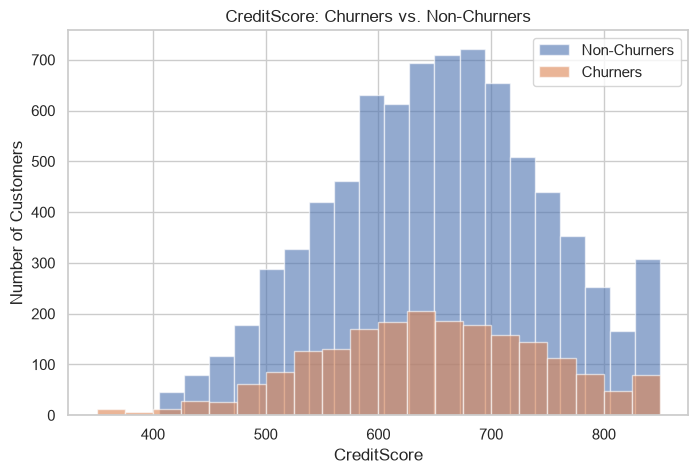

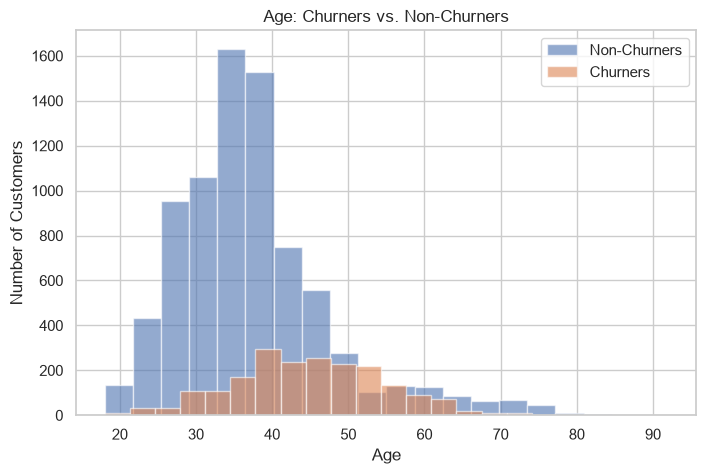

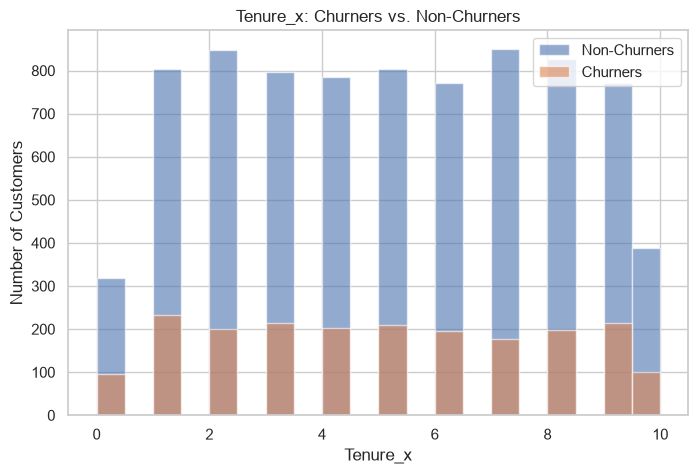

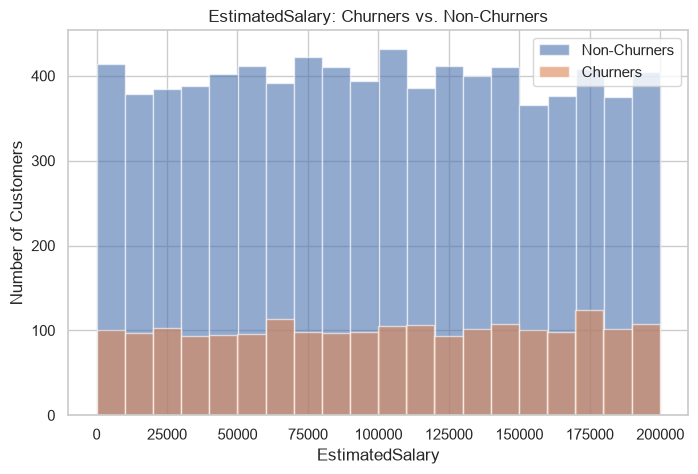

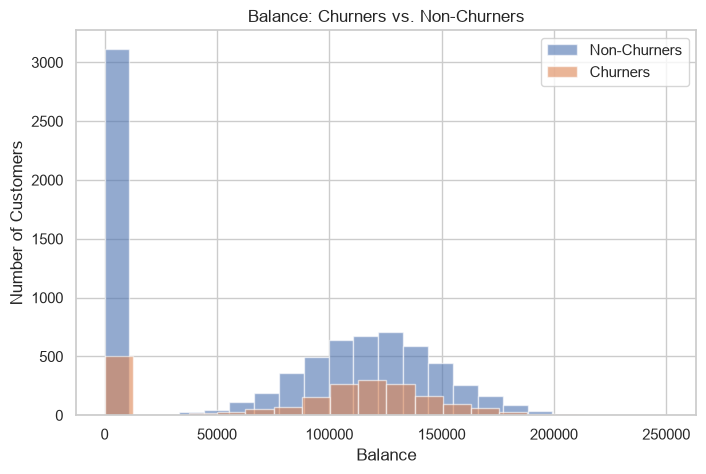

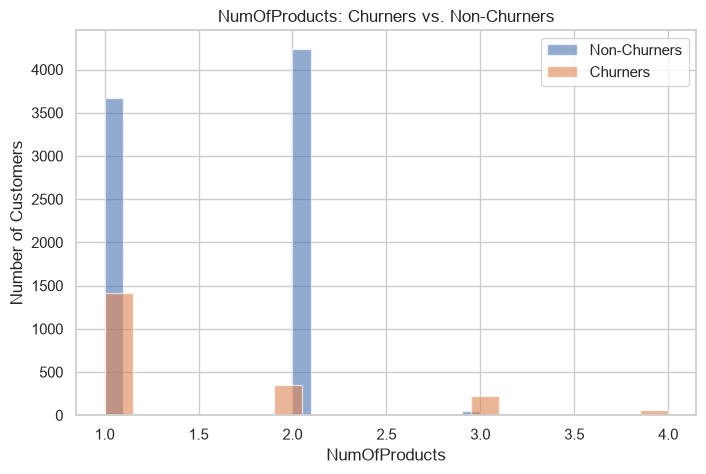

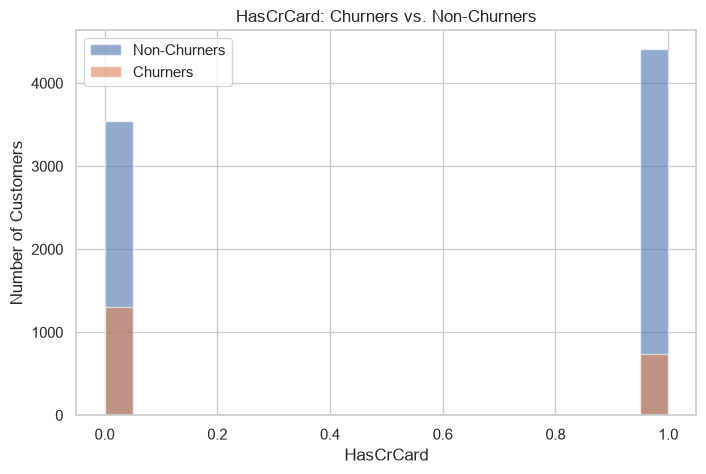

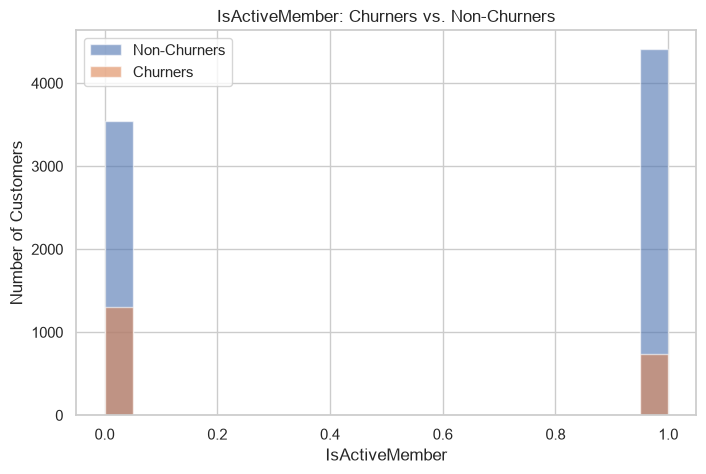

In [76]:
for column in numeric_columns:

    plt.figure(figsize=(8, 5))

    plt.hist(
        bank_df.loc[bank_df["Exited"] == 0, column],
        bins=20,
        alpha=0.6,
        label="Non-Churners"
    )

    plt.hist(
        bank_df.loc[bank_df["Exited"] == 1, column],
        bins=20,
        alpha=0.6,
        label="Churners"
    )

    plt.title(f"{column}: Churners vs. Non-Churners")
    plt.xlabel(column)
    plt.ylabel("Number of Customers")
    plt.legend()

    plt.show()

In [77]:
print(bank_df.columns.tolist())

['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure_x', 'EstimatedSalary', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'Exited']


In [78]:
model_df = bank_df.drop(
    columns=["CustomerId", "Surname"]
).copy()

In [79]:
print(model_df.head())
print(model_df.columns.tolist())
print(model_df.shape)

   CreditScore Geography  Gender   Age  Tenure_x  EstimatedSalary    Balance  \
0          619    France  Female  42.0         2        101348.88       0.00   
1          608     Spain  Female  41.0         1        112542.58   83807.86   
2          502    France  Female  42.0         8        113931.57  159660.80   
3          699    France  Female  39.0         1         93826.63       0.00   
4          850     Spain  Female  43.0         2         79084.10  125510.82   

   NumOfProducts  HasCrCard  IsActiveMember  Exited  
0              1          1               1       1  
1              1          1               1       0  
2              3          0               0       1  
3              2          0               0       0  
4              1          1               1       0  
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure_x', 'EstimatedSalary', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'Exited']
(10000, 11)


In [80]:
print(model_df["Exited"].value_counts())

Exited
0    7963
1    2037
Name: count, dtype: int64


In [81]:
categorical_columns = model_df.select_dtypes(
    include=["object", "category"]
).columns

print(categorical_columns.tolist())

['Geography', 'Gender']


C:\Users\Admin\AppData\Local\Temp\ipykernel_17244\463834160.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = model_df.select_dtypes(


In [82]:
model_df = pd.get_dummies(
    model_df,
    columns=categorical_columns,
    drop_first=True
)

In [83]:
print(model_df.head())

   CreditScore   Age  Tenure_x  EstimatedSalary    Balance  NumOfProducts  \
0          619  42.0         2        101348.88       0.00              1   
1          608  41.0         1        112542.58   83807.86              1   
2          502  42.0         8        113931.57  159660.80              3   
3          699  39.0         1         93826.63       0.00              2   
4          850  43.0         2         79084.10  125510.82              1   

   HasCrCard  IsActiveMember  Exited  Geography_Germany  Geography_Spain  \
0          1               1       1              False            False   
1          1               1       0              False             True   
2          0               0       1              False            False   
3          0               0       0              False            False   
4          1               1       0              False             True   

   Gender_Male  
0        False  
1        False  
2        False  
3        Fal

In [84]:
print(model_df.dtypes)

CreditScore            int64
Age                  float64
Tenure_x               int64
EstimatedSalary      float64
Balance              float64
NumOfProducts          int64
HasCrCard              int64
IsActiveMember         int64
Exited                 int64
Geography_Germany       bool
Geography_Spain         bool
Gender_Male             bool
dtype: object


In [85]:
print(
    model_df.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()
)

[]


In [86]:
model_df["balance_v_income"] = (
    model_df["Balance"] /
    model_df["EstimatedSalary"]
)

In [87]:
print(
    model_df[
        ["Balance", "EstimatedSalary", "balance_v_income"]
    ].head()
)

     Balance  EstimatedSalary  balance_v_income
0       0.00        101348.88          0.000000
1   83807.86        112542.58          0.744677
2  159660.80        113931.57          1.401375
3       0.00         93826.63          0.000000
4  125510.82         79084.10          1.587055


In [88]:
print(
    "Infinite values:",
    np.isinf(model_df["balance_v_income"]).sum()
)

print(
    "Missing values:",
    model_df["balance_v_income"].isna().sum()
)

Infinite values: 0
Missing values: 0


<Figure size 800x500 with 0 Axes>

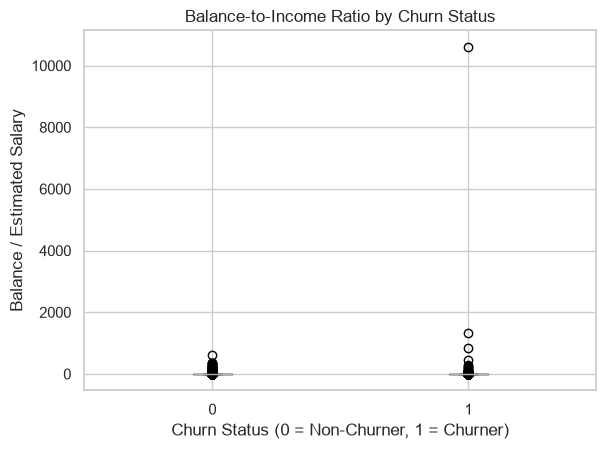

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

model_df.boxplot(
    column="balance_v_income",
    by="Exited"
)

plt.title("Balance-to-Income Ratio by Churn Status")
plt.suptitle("")
plt.xlabel("Churn Status (0 = Non-Churner, 1 = Churner)")
plt.ylabel("Balance / Estimated Salary")

plt.show()